In [1]:
import sys, os
from pathlib import Path

# always run from repo root
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
    os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

CKPT_DIR = REPO_ROOT / 'checkpoints' / 'spatial_ridge'
print('CKPT_DIR:', CKPT_DIR)
print('checkpoints found:', len(list(CKPT_DIR.glob('*.npz'))))

CKPT_DIR: /home/yy3658/NeurObjectGen/checkpoints/spatial_ridge
checkpoints found: 8


## Load all checkpoints

In [2]:
rows = []
for path in sorted(CKPT_DIR.glob('*.npz')):
    try:
        ckpt = np.load(path, allow_pickle=True)
        ckpt['alpha']  # trigger zip read to catch corrupt files
    except Exception as e:
        print(f'Skipping {path.name}: {e}')
        continue
    target = str(ckpt.get('target', np.array(['latent']))[0])
    row = dict(
        path       = path,
        name       = path.stem,
        target     = target,
        image_size = int(ckpt['image_size'][0]),
        n_components = int(ckpt['n_components'][0]),
        alpha      = float(ckpt['alpha'][0]),
        n_neural_pcs = int(ckpt['n_neural_pcs'][0]) if 'n_neural_pcs' in ckpt else 0,
        train_r2   = float(ckpt['train_r2_mean'][0]) if 'train_r2_mean' in ckpt else float('nan'),
        val_r2     = float(ckpt['val_r2_mean'][0]),
        test_r2    = float(ckpt['test_r2_mean'][0]),
        val_2afc   = float(ckpt['val_2afc'][0]),
        test_2afc  = float(ckpt['test_2afc'][0]),
    )
    rows.append(row)

df = pd.DataFrame(rows)
if df['train_r2'].notna().any():
    df['overfit'] = df['train_r2'] - df['val_r2']
else:
    df['overfit'] = float('nan')
df_pixel = df[df['target'] == 'pixel'].copy()
print(f"{len(df)} checkpoints total, {len(df_pixel)} pixel-target")
df_pixel.sort_values('val_r2', ascending=False).drop(columns='path').round(4)

8 checkpoints total, 5 pixel-target


,name,target,image_size,n_components,alpha,n_neural_pcs,train_r2,val_r2,test_r2,val_2afc,test_2afc,overfit
7,ridge_pixel_K64_a1e+10,pixel,32,64,1.000000e+10,100,0.0042,-0.0301,-0.0342,0.5576,0.5245,0.0343
4,ridge_pixel_K32_a1e+08,pixel,16,32,1.000000e+08,50,0.1373,-0.0385,-0.0421,0.5551,0.5233,0.1759
5,ridge_pixel_K64_a1e+04,pixel,16,64,1.000000e+04,50,0.2451,-0.0628,-0.0709,0.5400,0.5163,0.3080
3,ridge_pixel_K32_a1e+04,pixel,16,32,1.000000e+04,50,0.2497,-0.0665,-0.0758,0.5400,0.5192,0.3162
6,ridge_pixel_K64_a1e+06,pixel,32,64,1.000000e+06,100,0.4912,-0.0863,-0.0914,0.5502,0.5237,0.5775


## Sweep heatmaps: val R² and 2AFC

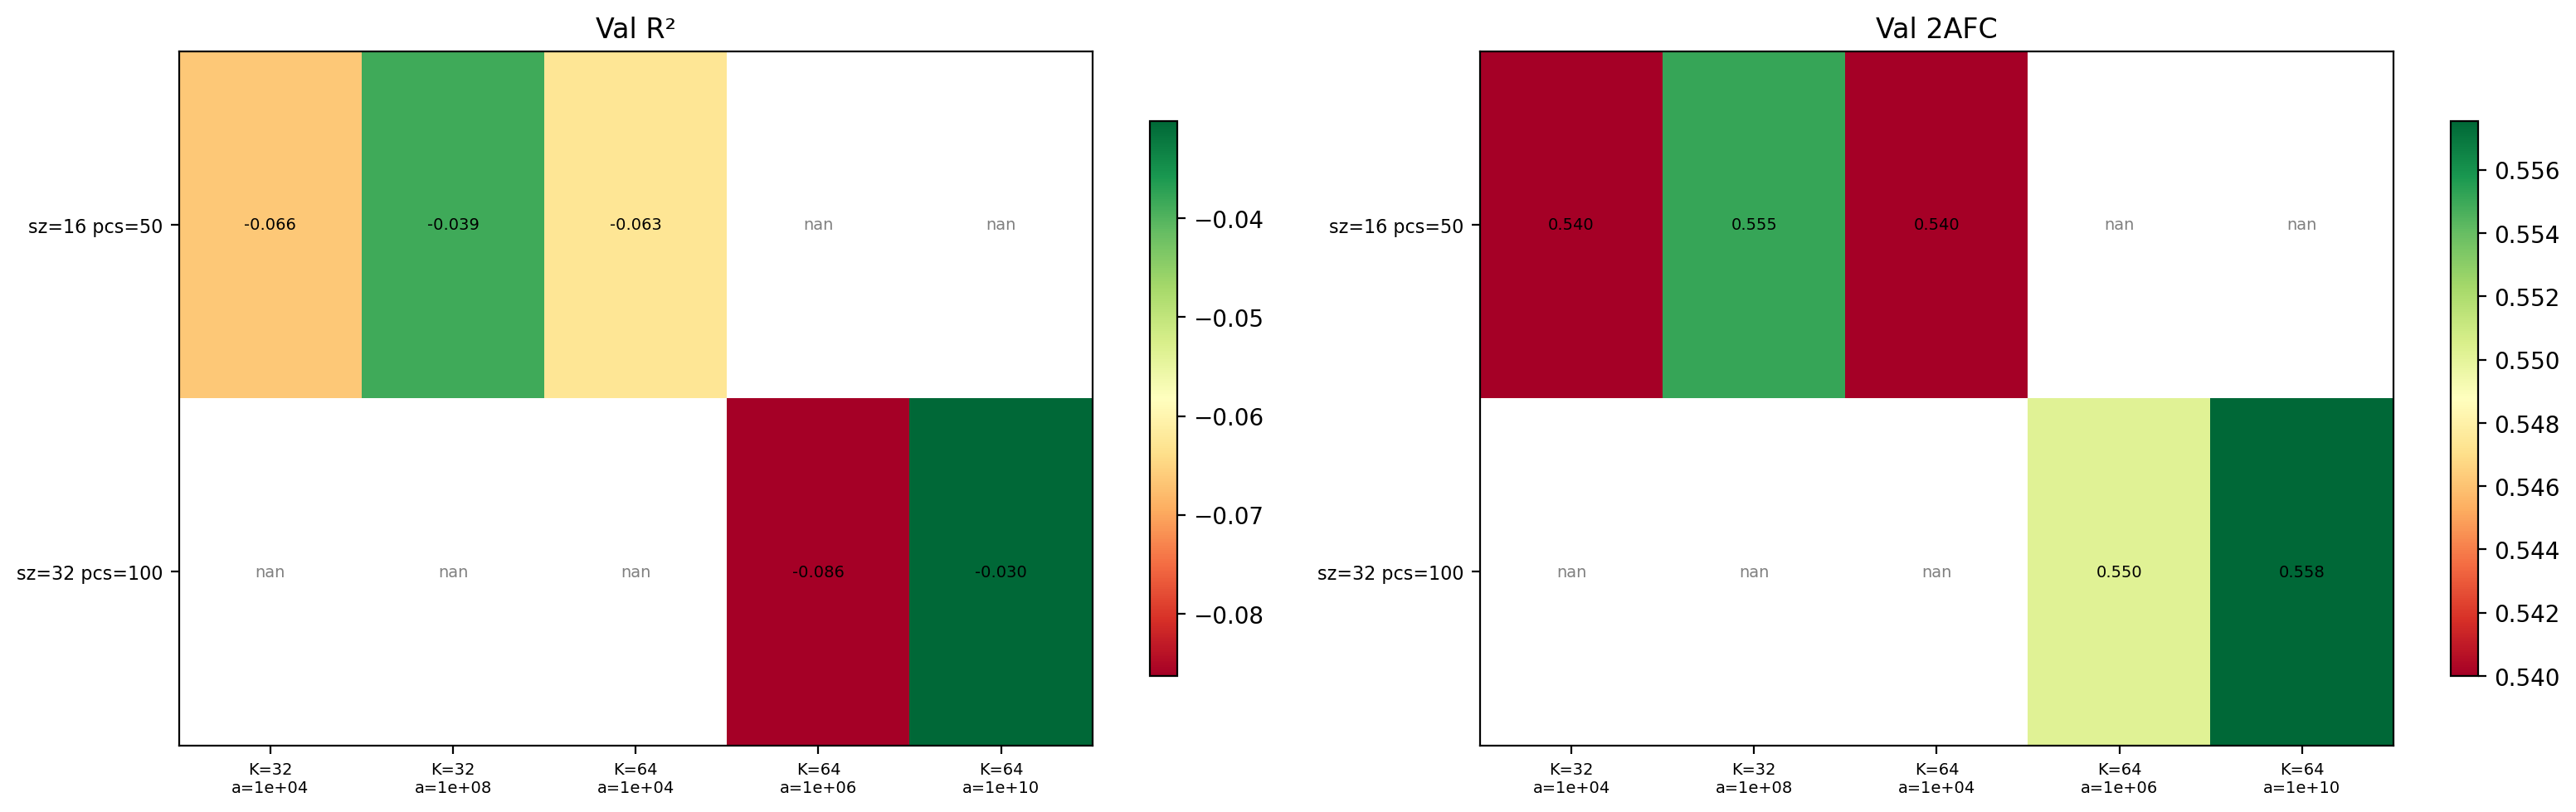

In [3]:
import itertools

def sweep_heatmap(df, metric, title, ax, fmt='.3f'):
    pivot = df.pivot_table(
        index=['image_size', 'n_neural_pcs'],
        columns=['n_components', 'alpha'],
        values=metric,
    )
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'K={k}\na={a:.0e}' for k, a in pivot.columns], fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'sz={s} pcs={p}' for s, p in pivot.index], fontsize=8)
    for i, j in itertools.product(range(pivot.shape[0]), range(pivot.shape[1])):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:{fmt}}', ha='center', va='center', fontsize=7,
                color='black' if not np.isnan(v) else 'gray')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)

if len(df_pixel) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sweep_heatmap(df_pixel, 'val_r2',   'Val R²',   axes[0])
    sweep_heatmap(df_pixel, 'val_2afc', 'Val 2AFC', axes[1])
    plt.tight_layout()
    plt.show()
else:
    print('No pixel-target checkpoints yet.')

## Train vs val R²: overfitting diagnosis

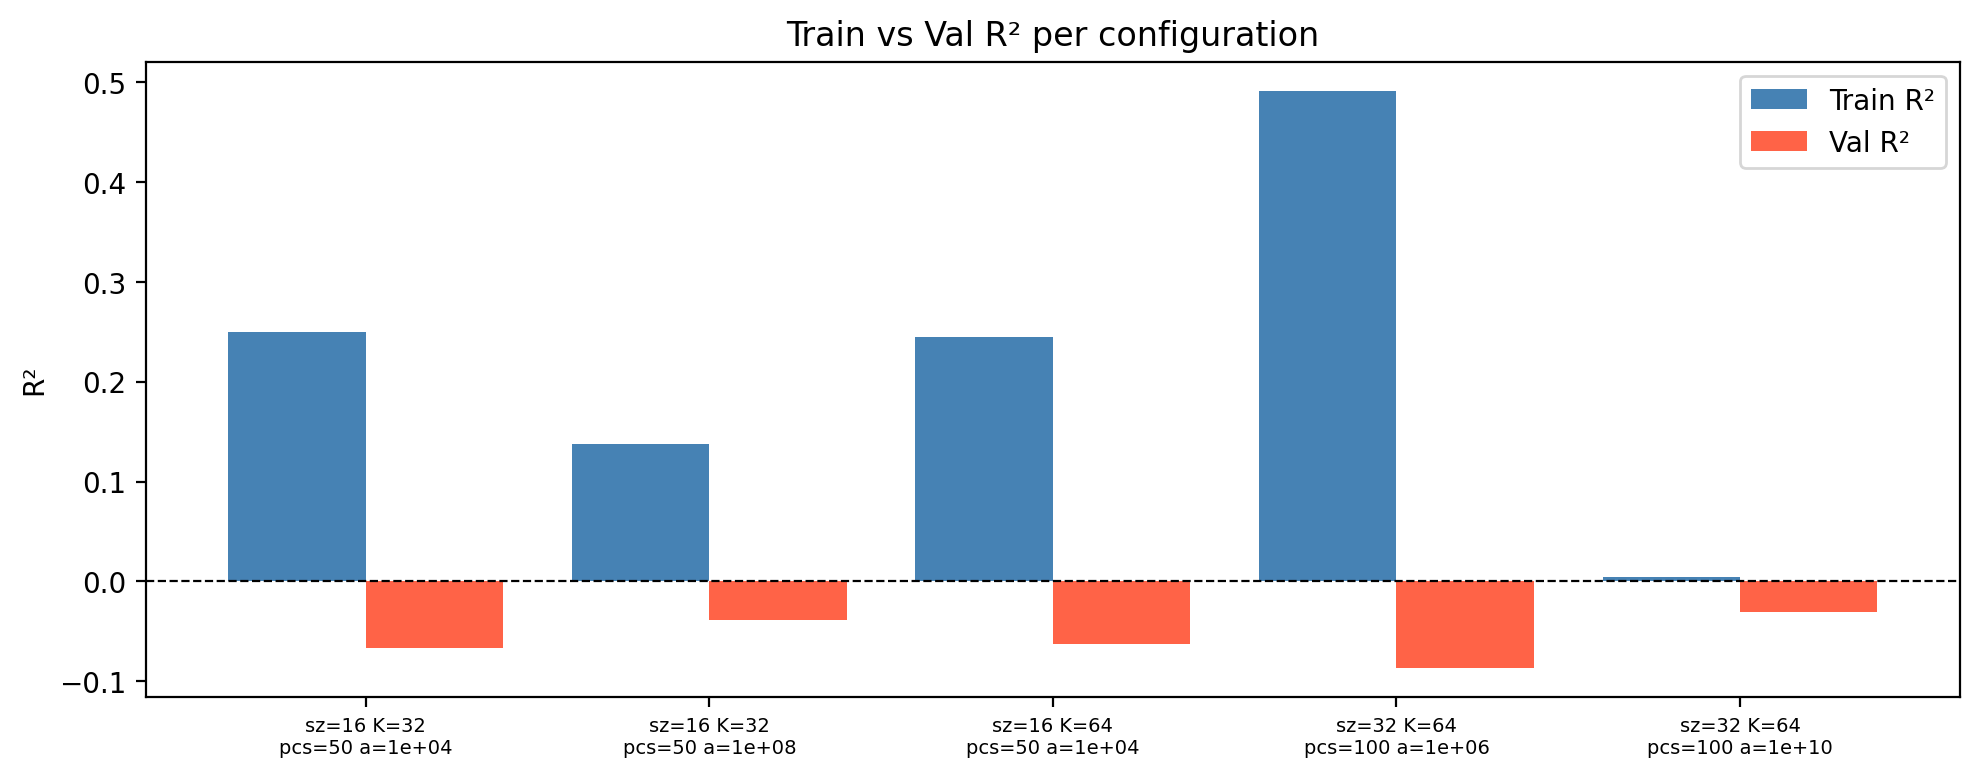

In [4]:
if len(df_pixel) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(df_pixel))
    labels = [f"sz={r.image_size} K={r.n_components}\npcs={r.n_neural_pcs} a={r.alpha:.0e}"
              for _, r in df_pixel.iterrows()]
    ax.bar(x - 0.2, df_pixel['train_r2'], 0.4, label='Train R²', color='steelblue')
    ax.bar(x + 0.2, df_pixel['val_r2'],   0.4, label='Val R²',   color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('R²')
    ax.set_title('Train vs Val R² per configuration')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Best checkpoint: reconstruct predicted vs actual images

In [5]:
from config_const import N_STIMULI, N_TRAIN, N_VAL, SEED
from data_utils.rust_loader import make_rust_loader
from generation.latent_cache import build_pixel_targets

# pick best by val_r2
best = df_pixel.sort_values('val_r2', ascending=False).iloc[0]
print(f"Best: {best['name']}  val_r2={best['val_r2']:.4f}  val_2afc={best['val_2afc']:.3f}")

ckpt = np.load(best['path'], allow_pickle=True)
W      = ckpt['W']
Z_mean = ckpt['pca_mean']
V      = ckpt['pca_V']
hw     = int(ckpt['image_size'][0])

# neural features
_, val_loader, _ = make_rust_loader(batch_size=256, use_embeddings=False)
X_val = torch.cat([n for n, _ in val_loader], dim=0).numpy().reshape(N_VAL, -1)

# apply neural PCA if present
if 'neural_pca_mean' in ckpt:
    X_val = (X_val - ckpt['neural_pca_mean']) @ ckpt['neural_pca_V']

# predict
Y_pred = X_val @ W                        # (N_VAL, K)
pixels_pred = Y_pred @ V.T + Z_mean       # (N_VAL, H*W)
pixels_pred = np.clip(pixels_pred, 0, 1)

# actual targets
targets = build_pixel_targets(hw).numpy()  # (N_STIMULI, H*W)
rng = np.random.default_rng(SEED)
perm = rng.permutation(N_STIMULI)
val_idx = perm[N_TRAIN:N_TRAIN + N_VAL]
pixels_true = targets[val_idx]

Best: ridge_pixel_K64_a1e+10  val_r2=-0.0301  val_2afc=0.558


Loading Rust sessions: 100%|██████████| 19/19 [00:25<00:00,  1.34s/it]
/home/yy3658/HexPred/object_response/get_rust_response.py:175: RuntimeWarning: Mean of empty slice
  avg_data[i] = np.nanmean(all_data[i], axis=0)
Loading stimuli: 100%|██████████| 300/300 [00:02<00:00, 111.28it/s]


RUST loaders created: train=200, val=50, test=50, neurons=6802, time=25, target=(3, 224, 224)
Built pixel targets: (300, 1024)


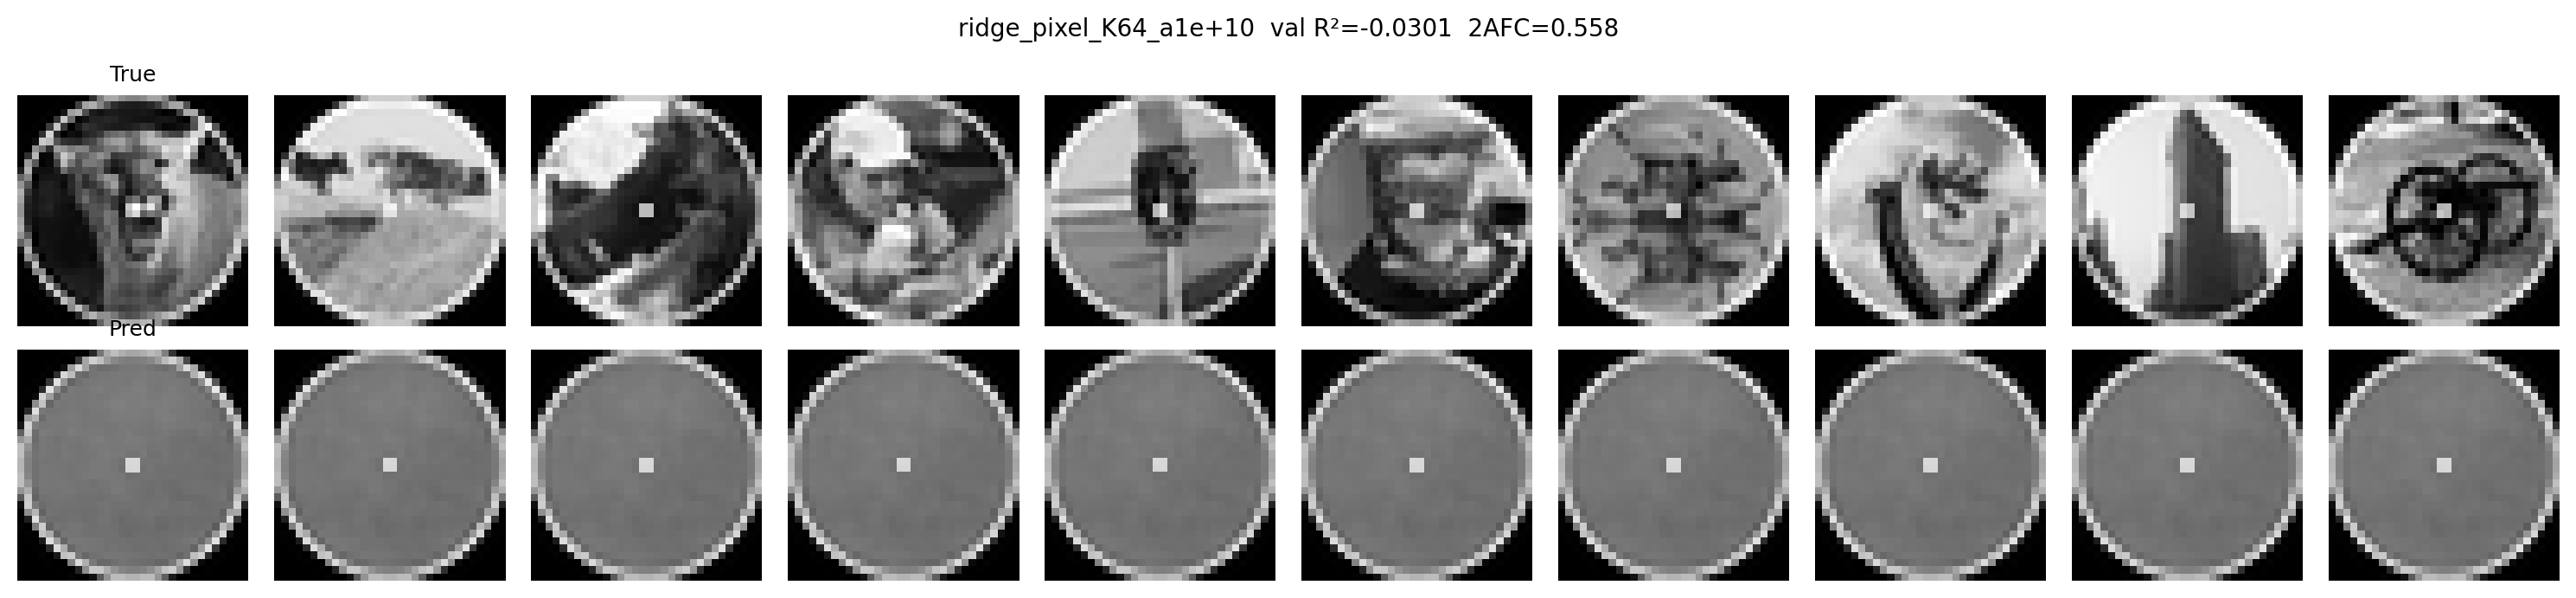

In [6]:
N_SHOW = 10
fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 1.5, 3.5))

for i in range(N_SHOW):
    for row, px, label in [
        (0, pixels_true[i], 'True'),
        (1, pixels_pred[i], 'Pred'),
    ]:
        axes[row, i].imshow(px.reshape(hw, hw), cmap='gray', vmin=0, vmax=1)
        axes[row, i].axis('off')
        if i == 0:
            axes[row, i].set_title(label, fontsize=9)

plt.suptitle(f"{best['name']}  val R²={best['val_r2']:.4f}  2AFC={best['val_2afc']:.3f}",
             fontsize=10)
plt.tight_layout()
plt.show()

## Per-component R² distribution (best checkpoint)

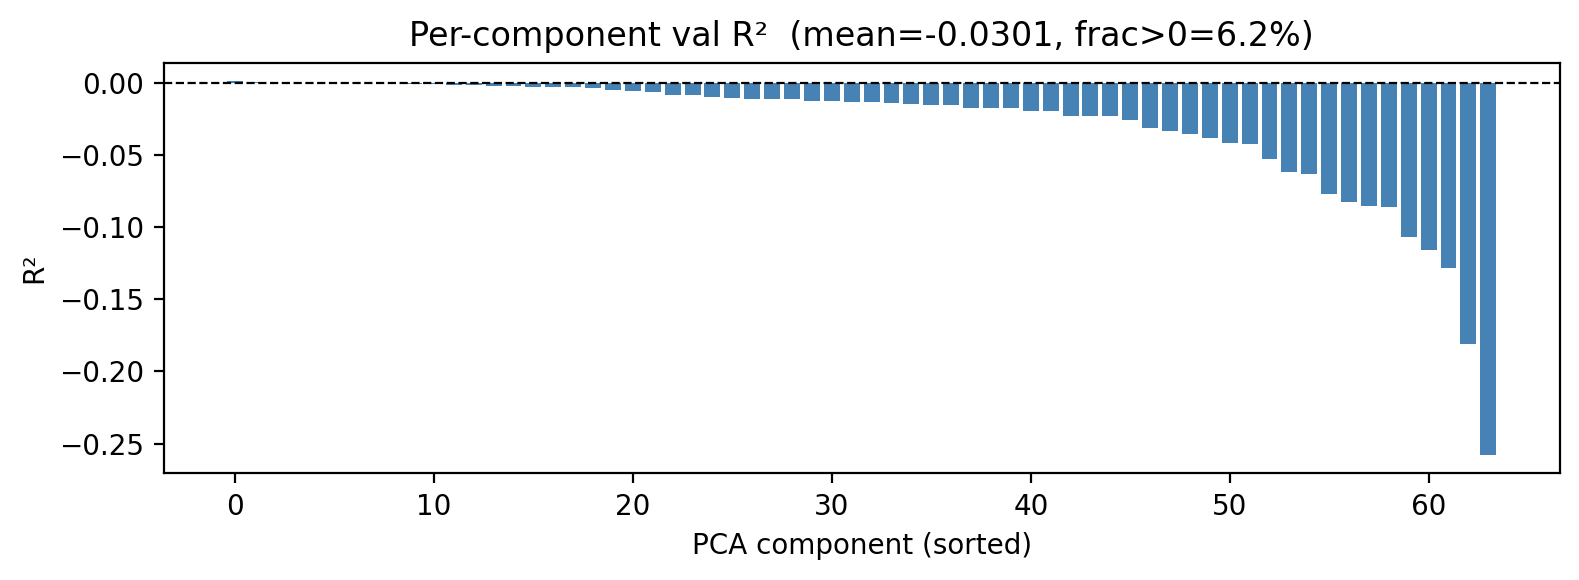

In [7]:
from eval.metrics import r2_per_component

Y_true = (pixels_true - Z_mean) @ V
r2 = r2_per_component(Y_pred, Y_true)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(r2)), np.sort(r2)[::-1], color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('PCA component (sorted)')
ax.set_ylabel('R²')
ax.set_title(f'Per-component val R²  (mean={r2.mean():.4f}, frac>0={(r2>0).mean()*100:.1f}%)')
plt.tight_layout()
plt.show()